# Load pyspark

In [16]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()
from pyspark import sql
from pyspark.sql.functions import col
from typing import Mapping, Sequence, Tuple

# Load Data

In [2]:
visit_occurrence = spark.read.csv("visit_occurrence", inferSchema=True,header=True)
condition = spark.read.csv("condition", inferSchema=True,header=True)
person = spark.read.csv("person", inferSchema=True,header=True)
concept = spark.read.csv("concept", inferSchema=True,header=True)
measurement = spark.read.csv("measurement", inferSchema=True,header=True)
death = spark.read.csv("death", inferSchema=True,header=True)

# Run Scripts with Example Conditions

To demonstrate how the pyspark scripts work, we will be gathering some test data. We will use the conditions_flag script to pull for patients with essential hypertension (SNOMED code 320128). We will use the vitals script to pull for patients with a systolic blood pressure greater than 140. Lastly, we will use the demographics script to pull for patients ages 40-60. 

In [3]:
%load_ext autoreload
%autoreload 1
%aimport vitals
%aimport demographics
%aimport conditions_flags

In [24]:
# flag for patients with essential hypertension at visit
conditions = conditions_flags.condition_pull(spark,concept,condition, codes=[320128])
# filter for patients who had systolic blood pressure greater than 140 at visit
measures = vitals.vitals_pull(spark, measurement, concept).filter(col("systolic_blood_pressure_min")>140)
# get all patients who were 50-60 years old at visit start
demo = demographics.demographic_pull(spark, visit_occurrence, person, death, visit_age=[40,60])

Let's join the dataframes we derived to get patients who were 40-60 years old at visit start and had systolic blood pressure greater than 140. The final dataframe will include a flag for essential hypertension (SNOMED code 320128).

In [25]:
# join dataframes to get patients who were 40-60 years old at visit start and 
# had systolic blood pressure greater than 140. Include flags for essential hypertension. 
exmaple_df = demo.join(measures, on="visit_occurrence_id").join(conditions, on="visit_occurrence_id")
exmaple_df.show(1,truncate=False, vertical=True)

-RECORD 0--------------------------------------------
 visit_occurrence_id           | 19389               
 person_id                     | 399                 
 gender_concept_id             | 8532                
 birth_datetime                | 1970-01-03 00:00:00 
 gender_source_value           | F                   
 race_source_value             | white               
 ethnicity_source_value        | nonhispanic         
 visit_start_datetime          | 2021-09-04 00:00:00 
 visit_end_datetime            | 2021-09-04 00:00:00 
 visit_length                  | 0                   
 death_date                    | null                
 visit_age                     | 51                  
 age                           | 53                  
 body_temperature_max          | null                
 body_temperature_min          | null                
 body_temperature_mean         | null                
 body_weight_max               | 91.1                
 body_weight_min            

From the sample putput above, we can see that even though this patient had a mean systolic blood pressure of 140, which is considered within the range for a hypertension diagnosis, they were not recorded to have essential hypertension, as indicated by the '320128' column (named after the SNOMED code for essential hypertension). There are several SNOMED codes for hypertension so it could be that they were recorded to have another type of hypertension.

# EDA Plots

Let's create some plots to do some basic EDA. Because pyspark does not have any visualization capabilities, we must convert the spark dataframe to a pandas dataframe first.

In [116]:
x = ["visit_start_datetime", "visit_end_datetime", "birth_datetime", "death_date"]

In [136]:
viz_df = exmaple_df.select([c for c in exmaple_df.columns if c not in {"visit_start_datetime", "visit_end_datetime", "birth_datetime", "death_date"}])
viz_df = viz_df.toPandas()

Now, we can plot the data.

[Text(0.5, 1.0, 'Distribution of Patients with Essential Hypertension'),
 Text(0.5, 0, 'Hypertension')]

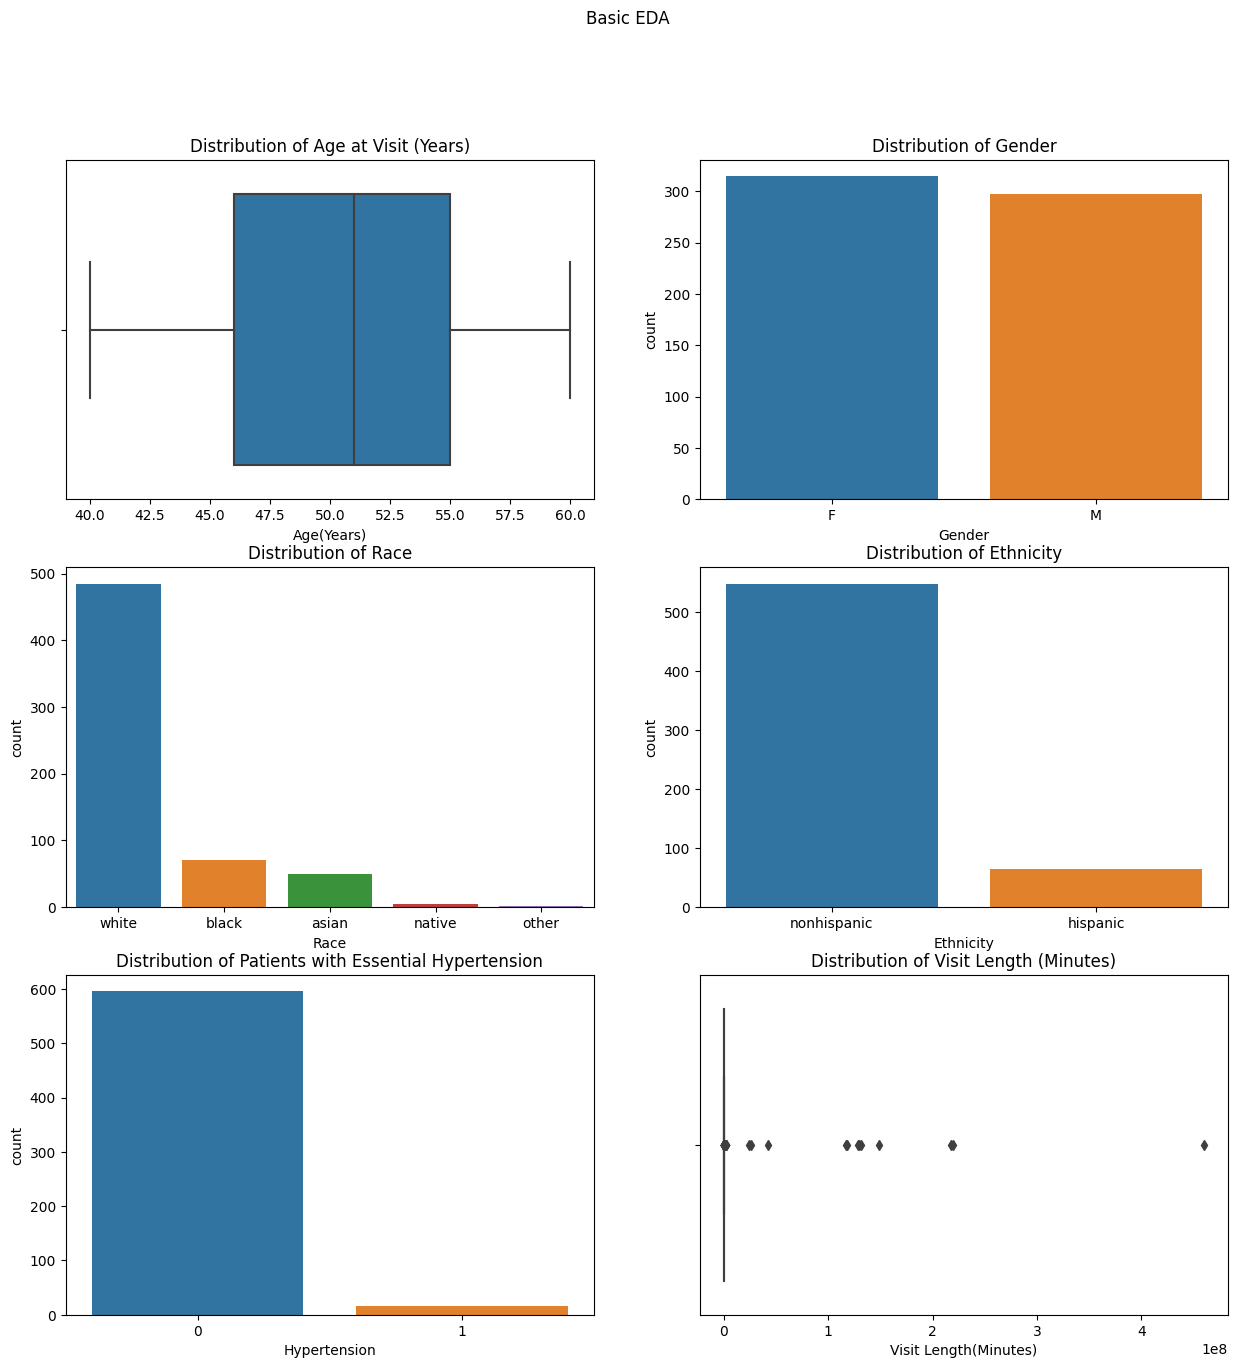

In [134]:
from matplotlib.pyplot import xlabel
from matplotlib import pyplot as plt
from numpy import log10
import seaborn as sns

fig, axes = plt.subplots(3,2, figsize=(15,15), sharey=False)
fig.suptitle('Basic EDA')

sns.boxplot(ax=axes[0,0],x=viz_df['visit_age']).set(title="Distribution of Age at Visit (Years)", xlabel="Age(Years)")

sns.countplot(ax=axes[0,1],x=viz_df['gender_source_value']).set(title="Distribution of Gender", xlabel="Gender")

sns.countplot(ax=axes[1,0],x=viz_df['race_source_value']).set(title="Distribution of Race", xlabel="Race")

sns.countplot(ax=axes[1,1],x=viz_df['ethnicity_source_value']).set(title="Distribution of Ethnicity", xlabel="Ethnicity")

sns.boxplot(ax=axes[2,1],x=viz_df['visit_length']).set(title="Distribution of Visit Length (Minutes)", xlabel="Visit Length(Minutes)")

sns.countplot(ax=axes[2,0],x=viz_df['320128']).set(title="Distribution of Patients with Essential Hypertension", xlabel="Hypertension")


Based on the plots, we can draw some prelimanary conclusions about this dataset:

* Because few visits included time information (besides the date), most visit lengths are recorded as lasting 0 minutes. 
* There were far more White and Non-Hispanic patients than any other rate or ethnicity. If one were to draw conclusions or make models based on this data, they would have to account for bias due to these variables.
* Despite filtering for a blood pressure value that is in the range for hypertension, most patients were not flagged for essential hypertension. As mentioned earlier, this could be due to the fact, multiple SNOMED codes exist for hypertension. 